# Chapter 10 — From Analog Ritual to Digital Reality
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 10 — From Analog Ritual to Digital Reality.

Between the 1940s and the 1980s the strain gage changed less than the machinery that read it. This notebook puts numbers on two things that changed with that machinery:

1. **The resolution of the record.** A light-beam oscillograph wrote strain as a trace on photographic paper, and someone measured the trace afterward with a film scale. A digital system writes a number, and its smallest step is one count of the analog-to-digital converter. The chapter's Eq. 10.1 turns that count into microstrain:

$$\varepsilon_{\text{LSB}} = \frac{4\,V_{\text{FS}}}{2^{N}\,G\,GF\,V_{\text{ex}}} \qquad (10.1)$$

2. **The throughput of the record.** A static test is read gage by gage at every load step. The time to read it is the number of readings divided by the rate at which they are taken (Eq. 10.2):

$$t = \frac{n_g\,n_L}{r} \qquad (10.2)$$

The reading rates come from the sources cited in the chapter: P. H. R. Lane of the British Welding Research Association (a three-person manual team, about 600 readings an hour, 1957); an automatic recorder described in *Product Engineering* (48 gages a minute, 1948); the Dymec DY-2010 scanner and digital voltmeter (10 channels a second, 1965); and the data system of NASA Dryden's Flight Loads Research Facility (1,000 channels sampled 10 times a second each through 12-bit converters, 1981; 100 gages at six load steps are six scans, 0.6 s). The oscillograph reading resolution comes from NASA's account of film reading at Muroc (a film scale read to 0.01 in on a blurred trace, 0.005 in on a sharp one); the 25 mm (1 in) trace swing is an illustrative choice. NATO's flight-test manual (AGARD-AG-160) gives photographic trace recorders 0.5 to 3 percent of full scale, about 5 to 7.6 equivalent bits. Everything else is the chapter's round-number worked example.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12.5, 'axes.titlesize': 13.5})

# Generated figures are written next to the chapter's other media.
# The file name matches the \includegraphics call in Chapter 10.
OUT_DIR = Path("../src/media/ch10")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — One count, in microstrain (Eq. 10.1)

A quarter bridge gives $V_o = V_{\text{ex}}\,GF\,\varepsilon/4$ (Chapter 26, Eq. 26.3). An amplifier of gain $G$ scales that output onto a converter whose full input span is $V_{\text{FS}}$, divided into $2^N$ counts. One count is therefore $V_{\text{FS}}/2^N$ at the converter, $V_{\text{FS}}/(2^N G)$ at the bridge, and Eq. 10.1 in strain.

The values below are the chapter's first worked example: a 12-bit converter spanning 10 V (±5 V), gain 1,000, gage factor 2.00, 5 V excitation.

In [2]:
def strain_per_count(n_bits, v_fs=10.0, gain=1000.0, gf=2.00, v_ex=5.0):
    # Eq. 10.1: strain represented by one converter count, quarter bridge (dimensionless)
    return 4.0 * v_fs / (2.0 ** n_bits * gain * gf * v_ex)


def strain_span(v_fs=10.0, gain=1000.0, gf=2.00, v_ex=5.0):
    # Full strain span that fills the converter's input span (dimensionless)
    return 4.0 * v_fs / (gain * gf * v_ex)


SPAN_UE = strain_span() * 1e6
print(f"Strain span that fills the converter: {SPAN_UE:,.0f} microstrain (+/-{SPAN_UE/2:,.0f})")
for n in (8, 12, 16):
    print(f"{n:2d}-bit: one count = {strain_per_count(n)*1e6:7.3f} microstrain")

Strain span that fills the converter: 4,000 microstrain (+/-2,000)
 8-bit: one count =  15.625 microstrain
12-bit: one count =   0.977 microstrain
16-bit: one count =   0.061 microstrain


---
## 2 — The oscillograph record on the same scale

Put the same 4,000 µε span on a photographic trace that swings 25 mm (1 in) across the paper, and read it with a film scale to the nearest 0.25 mm (0.01 in). The smallest readable change is the reading resolution divided by the deflection, times the strain span. Expressed as an *equivalent number of bits*, $\log_2$(deflection / reading resolution), the record is a converter of between six and seven bits.

In [3]:
DEFLECTION_MM = 25.0     # full trace deflection for the strain span (about 1 in)
READ_MM       = 0.25     # film-scale reading resolution (0.01 in)

osc_step_ue = SPAN_UE * READ_MM / DEFLECTION_MM
osc_bits = np.log2(DEFLECTION_MM / READ_MM)
print(f"Oscillograph: smallest readable step = {osc_step_ue:.0f} microstrain "
      f"({100*READ_MM/DEFLECTION_MM:.1f}% of span), equivalent to {osc_bits:.1f} bits")

ratio = osc_step_ue / (strain_per_count(12) * 1e6)
print(f"12-bit count is {ratio:.0f} times finer than the film reading")

Oscillograph: smallest readable step = 40 microstrain (1.0% of span), equivalent to 6.6 bits
12-bit count is 41 times finer than the film reading


---
## 3 — Reading a 100-gage static test (Eq. 10.2)

The second worked example: 100 gages read at a zero reading and five load increments, six readings of every gage in all.

In [4]:
N_GAGES = 100
N_LOADS = 6               # zero plus five load increments
N_READ = N_GAGES * N_LOADS

# (label, readings per second, short source note)
methods = [
    ("Manual team of three\n(Lane, 1957)",           600 / 3600, "600 readings/h"),
    ("Automatic recorder\n(1948)",              48 / 60,   "48 gages/min"),
    ("Scanner and DVM\n(Dymec DY-2010, 1965)", 10.0,      "10 channels/s"),
    # Dryden sampled every channel at 10 scans/s, so 100 gages give 1,000 readings/s:
    # six load steps need six scans, 0.6 s.
    ("Dryden loads lab, 10 scans/s\n(NASA, 1981)", 100 * 10.0, "10 scans/s"),
]

for label, rate, note in methods:
    t = N_READ / rate          # Eq. 10.2, seconds
    print(f"{label.replace(chr(10), ' '):55s} {note:>16s}: {t:10.2f} s  ({t/60:7.2f} min)")

Manual team of three (Lane, 1957)                         600 readings/h:    3600.00 s  (  60.00 min)
Automatic recorder (1948)                                   48 gages/min:     750.00 s  (  12.50 min)
Scanner and DVM (Dymec DY-2010, 1965)                      10 channels/s:      60.00 s  (   1.00 min)
Dryden loads lab, 10 scans/s (NASA, 1981)                     10 scans/s:       0.60 s  (   0.01 min)


---
## 4 — The figure

Panel (a) compares the smallest readable step of each record on the 4,000 µε span. Panel (b) compares the time to read the 100-gage test once through all six load steps. Both axes are logarithmic. Every bar carries a direct label and its own hatching, so the figure reads the same in the black-and-white edition.

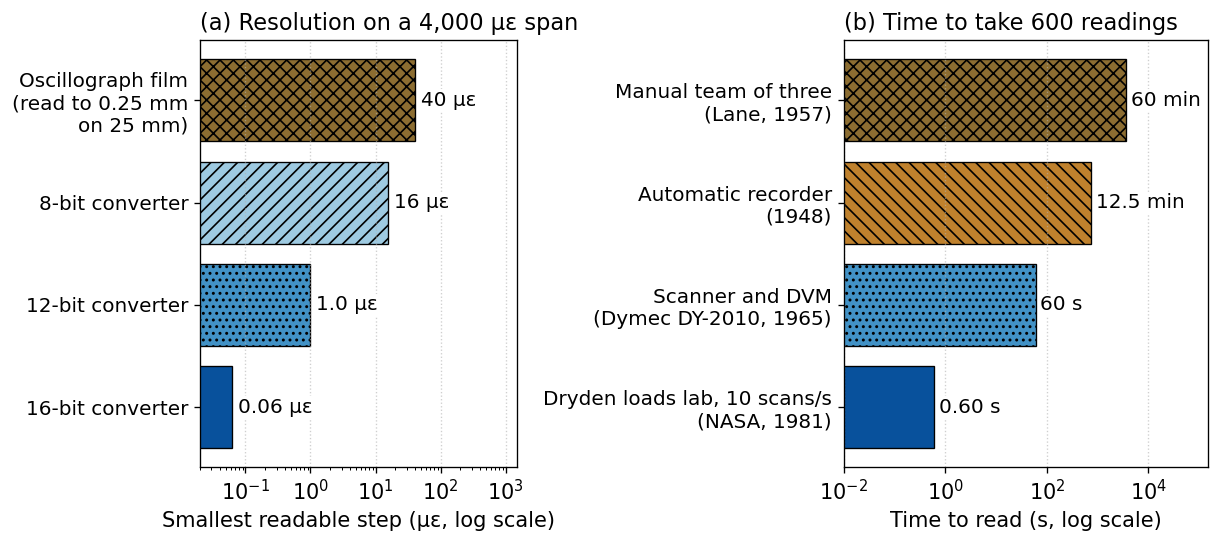

In [5]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(10.4, 4.7),
                               gridspec_kw={'width_ratios': [1.0, 1.15]})

# (a) resolution of the record
res_labels = ["Oscillograph film\n(read to 0.25 mm\non 25 mm)",
              "8-bit converter", "12-bit converter", "16-bit converter"]
res_vals = [osc_step_ue] + [strain_per_count(n) * 1e6 for n in (8, 12, 16)]
res_hatch = ['xxx', '///', '...', '']
res_color = ['#8c6d31', '#9ecae1', '#4292c6', '#08519c']
ya = np.arange(len(res_vals))[::-1]
bars = axa.barh(ya, res_vals, color=res_color, edgecolor='black', linewidth=0.8)
for b, h in zip(bars, res_hatch):
    b.set_hatch(h)
axa.set_xscale('log')
axa.set_xlim(0.02, 1500)
axa.set_yticks(ya)
axa.set_yticklabels(res_labels, fontsize=12)
axa.set_xlabel('Smallest readable step (µε, log scale)')
axa.set_title('(a) Resolution on a 4,000 µε span', loc='left')
for y, v in zip(ya, res_vals):
    txt = f"{v:.0f} µε" if v >= 10 else (f"{v:.1f} µε" if v >= 0.1 else f"{v:.2f} µε")
    axa.text(v * 1.25, y, txt, va='center', fontsize=12,
             bbox=dict(facecolor='white', edgecolor='none', pad=1.0))
axa.grid(True, axis='x', which='major', linestyle=':', alpha=0.6)

# (b) time to read the test
t_labels = [m[0] for m in methods]
t_vals = [N_READ / m[1] for m in methods]
t_hatch = ['xxx', '\\\\\\', '...', '']
t_color = ['#8c6d31', '#bf812d', '#4292c6', '#08519c']
yb = np.arange(len(t_vals))[::-1]
bars = axb.barh(yb, t_vals, color=t_color, edgecolor='black', linewidth=0.8)
for b, h in zip(bars, t_hatch):
    b.set_hatch(h)
axb.set_xscale('log')
axb.set_xlim(0.01, 1.5e5)
axb.set_yticks(yb)
axb.set_yticklabels(t_labels, fontsize=12)
axb.set_xlabel('Time to read (s, log scale)')
axb.set_title('(b) Time to take 600 readings', loc='left')


def fmt_t(s):
    if s >= 1200:
        return f"{s/60:.0f} min"
    if s >= 120:
        return f"{s/60:.1f} min"
    if s >= 1:
        return f"{s:.0f} s"
    return f"{s:.2f} s"


for y, v in zip(yb, t_vals):
    axb.text(v * 1.25, y, fmt_t(v), va='center', fontsize=12,
             bbox=dict(facecolor='white', edgecolor='none', pad=1.0))
axb.grid(True, axis='x', which='major', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig10_nb1_record_resolution.png', bbox_inches='tight', dpi=300)
plt.show()

---
## Where to take this next

- **Change the gain.** Halve the gain in `strain_per_count` and the strain span doubles while every count gets twice as coarse. Chapter 28 explains why a signal should fill most of the converter's span, and Chapter 31 what the converter's noise does to the counts it nominally has.
- **Add the reduction.** Reading is half of a static test. A 1941 account by Kenyon and Tobin gives about 20 minutes for two people to reduce one rosette graphically, and about one minute with a special slide rule. Add 10 rosettes reduced at the 5 load increments (the zero reading needs no solution), 50 solutions in all, and compare the totals with the reading times above.
- **Add drift.** Lane read quickly partly to limit the effect of zero drift. Give each gage a slow zero drift in µε per hour and see how much accumulates between its first and last reading for each method.